# K-Means Clustering of NYC Public School and MTA Subway Data

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
subway_df = pd.read_csv('../cleaned_data/MTA_Subway_Grouped_Data.csv')

subway_df.head()

,line,num_stations,station_latitudes,station_longitudes,station_census_tracts,station_zip_codes,station_boroughs,stop_names,mta_performance_data
0,1,38,"[40.889248, 40.884667, 40.878856, 40.874561, 4...","[-73.898583, -73.90087, -73.904834, -73.909831...","[285, 283, 283, 309, 303, 293, 283, 277, 269, ...","[10463, 10463, 10463, 10468, 10034, 10034, 100...","['Bx', 'Bx', 'Bx', 'M', 'M', 'M', 'M', 'M', 'M...","['Van Cortlandt Park-242 St', '238 St', '231 S...","[['2015-01-01', 76.2337806, 1], ['2015-02-01',..."
1,2,49,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 47.2874494, 1], ['2015-02-01',..."
2,3,34,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 68.6321563, 1], ['2015-02-01',..."
3,4,28,"[40.688246, 40.684359, 40.670682, 40.668897, 4...","[-73.980492, -73.977666, -73.958131, -73.93294...","[37, 35, 213, 351, 431, 419, 409, 403, 401, 23...","[11217, 11217, 11238, 11213, 10467, 10467, 104...","['Bk', 'Bk', 'Bk', 'Bk', 'Bx', 'Bx', 'Bx', 'Bx...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 48.4323757, 1], ['2015-02-01',..."
4,5,45,"[40.688246, 40.684359, 40.670682, 40.667883, 4...","[-73.980492, -73.977666, -73.958131, -73.95068...","[37, 35, 213, 319, 329, 804, 820, 826, 830, 78...","[11217, 11217, 11238, 11225, 11225, 11225, 112...","['Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 49.3452473, 1], ['2015-02-01',..."


In [3]:
schools_df = pd.read_csv('../cleaned_data/AllBoroughs_yearly_ratings.csv')
schools_df.head(10)

,School Building Number,QR Score,Assessment Time,Location Name,Primary Address,City,Zip,Census Tract,Community District,Latitude,Longitude
0,K544,6,2006-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,K544,6,2007-04-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,K544,7,2008-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,K544,6,2010-02-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,K544,0,2014-12-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,K337,6,2006-04-26,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644
6,K337,1,2007-05-23,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644
7,K337,7,2008-05-15,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644
8,K337,7,2009-05-02,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644
9,K337,5,2012-03-28,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600.0,313.0,40.59928,-73.99644


# Data Preparation

In [4]:
schools_df['Census Tract'] = schools_df['Census Tract'].astype(float).astype('Int64').astype(str)
schools_df.head(10)

,School Building Number,QR Score,Assessment Time,Location Name,Primary Address,City,Zip,Census Tract,Community District,Latitude,Longitude
0,K544,6,2006-04-12,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
1,K544,6,2007-04-28,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
2,K544,7,2008-03-15,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
3,K544,6,2010-02-10,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
4,K544,0,2014-12-03,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN
5,K337,6,2006-04-26,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644
6,K337,1,2007-05-23,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644
7,K337,7,2008-05-15,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644
8,K337,7,2009-05-02,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644
9,K337,5,2012-03-28,International High School at Lafayette,2630 BENSON AVENUE,BROOKLYN,11214.0,30600,313.0,40.59928,-73.99644


# Goal:
- Use train performance as a predictor of school performance

# Troubleshooting:
- Census Tracts do not match up between subway stations and schools; use zip codes instead for mapping
- Zip codes didn't help much; using latitude and longitude data instead

In [5]:
schools_dim = schools_df[['School Building Number', 'Latitude', 'Longitude', 'Census Tract', 'Zip', 'Assessment Time', 'QR Score']].copy()

schools_dim = schools_dim[schools_dim['Census Tract'] != '<NA>']

schools_dim.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score
5,K337,40.59928,-73.99644,30600,11214.0,2006-04-26,6
6,K337,40.59928,-73.99644,30600,11214.0,2007-05-23,1
7,K337,40.59928,-73.99644,30600,11214.0,2008-05-15,7
8,K337,40.59928,-73.99644,30600,11214.0,2009-05-02,7
9,K337,40.59928,-73.99644,30600,11214.0,2012-03-28,5


In [7]:
subway_df.tail() # 26 rows

,line,num_stations,station_latitudes,station_longitudes,station_census_tracts,station_zip_codes,station_boroughs,stop_names,mta_performance_data
21,R,45,"[40.76266, 40.764811, 40.764664, 40.759901, 40...","[-73.967258, -73.973347, -73.980658, -73.98413...","[114, 143, 137, 125, 113, 101, 76, 56, 52, 57,...","[10022, 10153, 10019, 10020, 10110, 10119, 101...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['Lexington Av/59 St', '5 Av/59 St', '57 St-7 ...","[['2015-01-01', 61.8342152, 1], ['2015-02-01',..."
22,RS,5,"[40.608382, 40.588034, 40.585307, 40.583209, 4...","[-73.815925, -73.813641, -73.820558, -73.82755...","[1072, 942, 942, 938, 938]","[11693, 11693, 11693, 11693, 11694]","['Q', 'Q', 'Q', 'Q', 'Q']","['Broad Channel', 'Beach 90 St', 'Beach 98 St'...","[['2015-01-01', 95.3841572, 1], ['2015-02-01',..."
23,SIR,21,"[40.643748, 40.636949, 40.627915, 40.621319, 4...","[-74.073643, -74.074835, -74.075162, -74.07140...","[3, 21, 21, 6, 50, 96, 96, 114, 122, 134, 132,...","[10301, 10301, 10301, 10301, 10304, 10304, 103...","['SI', 'SI', 'SI', 'SI', 'SI', 'SI', 'SI', 'SI...","['St George', 'Tompkinsville', 'Stapleton', 'C...",NaN
24,W,23,"[40.775036, 40.770258, 40.766779, 40.76182, 40...","[-73.912034, -73.917843, -73.921479, -73.92550...","[115, 125, 63, 59, 53, 31, 114, 143, 137, 125,...","[11105, 11102, 11102, 11106, 11106, 11101, 100...","['Q', 'Q', 'Q', 'Q', 'Q', 'Q', 'M', 'M', 'M', ...","['Astoria-Ditmars Blvd', 'Astoria Blvd', '30 A...","[['2016-11-01', 76.5017118, 1], ['2016-12-01',..."
25,Z,21,"[40.700492, 40.695178, 40.693879, 40.691324, 4...","[-73.828294, -73.84433, -73.851576, -73.867139...","[144, 26, 20, 4, 1178, 1174, 1198, 1198, 405, ...","[11415, 11418, 11421, 11421, 11208, 11208, 112...","['Q', 'Q', 'Q', 'Q', 'Bk', 'Bk', 'Bk', 'Bk', '...","['121 St', '104 St', 'Woodhaven Blvd', '75 St-...",NaN


In [8]:
schools_dim['Zip'] = schools_dim['Zip'].astype(float).astype('Int64').astype(str)
schools_dim.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score
5,K337,40.59928,-73.99644,30600,11214,2006-04-26,6
6,K337,40.59928,-73.99644,30600,11214,2007-05-23,1
7,K337,40.59928,-73.99644,30600,11214,2008-05-15,7
8,K337,40.59928,-73.99644,30600,11214,2009-05-02,7
9,K337,40.59928,-73.99644,30600,11214,2012-03-28,5


In [10]:
from sklearn.neighbors import BallTree
import ast
import numpy as np

# Build KDTree from all subway stations for efficient nearest neighbor search
all_stations_data = []
station_metadata = []

for _, row in subway_df.iterrows():
    station_line = row['line']
    raw_lats = row['station_latitudes']
    raw_lngs = row['station_longitudes']
    
    # Parse safely
    try:
        station_lats = ast.literal_eval(raw_lats) if isinstance(raw_lats, str) else list(raw_lats)
        station_lngs = ast.literal_eval(raw_lngs) if isinstance(raw_lngs, str) else list(raw_lngs)
    except (ValueError, SyntaxError, TypeError):
        continue
    
    # Check length match
    if len(station_lats) != len(station_lngs):
        continue
    
    for lat, lng in zip(station_lats, station_lngs):
        try:
            all_stations_data.append([float(lat), float(lng)])
            station_metadata.append(station_line)
        except (ValueError, TypeError):
            continue

# Validate before building tree
if len(all_stations_data) == 0:
    raise RuntimeError("No valid station coordinates found in subway_df")

# Build BallTree with haversine metric (expects radians)
coords_rad = np.radians(np.array(all_stations_data))
tree = BallTree(coords_rad, metric='haversine')

# Convert miles to radians (Earth radius ≈ 3959 miles)
EARTH_RADIUS_MILES = 3958.8
def miles_to_radians(miles):
    return miles / EARTH_RADIUS_MILES

def get_nearest_subway_lines(school_lat, school_lng):
    '''
    * Input: 
        - school_lat (float) - The latitude of the school's location
        - school_lng (float) - The longitude of the school's location
    * Output: 
        - nearest_lines (list) - List of unique nearest subway lines within 1.2 miles
    '''
    nearest_lines = []
    
    # Handle NaN values and check for finite values
    try:
        school_lat = float(school_lat)
        school_lng = float(school_lng)
        if not (np.isfinite(school_lat) and np.isfinite(school_lng)):
            return nearest_lines
    except (ValueError, TypeError):
        return nearest_lines
    
    # Query BallTree for all stations within 1.2 miles using haversine
    radius_rad = miles_to_radians(1.2)
    query_pt = np.radians([[school_lat, school_lng]])
    indices = tree.query_radius(query_pt, r=radius_rad)[0]
    
    # Return unique subway lines for all nearby stations
    for idx in indices:
        if 0 <= idx < len(station_metadata):
            nearest_lines.append(station_metadata[idx])
    
    return list(dict.fromkeys(nearest_lines))  # Preserve order + remove duplicates

schools_dim['Nearest_Subway_Stations'] = schools_dim.apply(
    lambda row: get_nearest_subway_lines(row['Latitude'], row['Longitude']), 
    axis=1
)

In [12]:
schools_dim.sample(25)

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations
4474,M507,40.76586,-73.98530,12700,10019,2014-03-22,7,"[N, Q, B, W, D, R, F, M, 1, 2, 3, 7, 4, 6, A, ..."
83,K425,40.60047,-73.94453,64200,11229,2008-03-05,7,"[B, Q]"
6378,Q349,40.71491,-73.79295,44602,11432,2016-05-12,0,"[F, Z, J, E]"
9,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[D, N]"
8228,X316,40.84273,-73.87891,37100,10460,2008-04-05,7,"[6, 2, 5]"
4311,M540,40.82485,-73.95023,21703,10031,2007-06-06,6,"[1, B, C, D, A, 2, 3]"
6826,X286,40.84273,-73.87891,15700,10460,2008-06-05,7,"[6, 2, 5]"
3032,M087,40.78534,-73.97138,16100,10024,2015-05-16,0,"[B, 2, C, 1, 6, 3, 5, 4, Q]"
3339,M116,40.74515,-73.97807,7000,10016,2008-10-09,6,"[L, R, N, W, 5, 6, F, 4, Q, M, E, C, 1, B, D, ..."
5148,Q040,40.69805,-73.78675,26000,11433,2008-05-23,7,"[J, E, Z, F]"


In [20]:
schools_wo_close_stations = schools_dim[schools_dim['Nearest_Subway_Stations'].apply(len) == 0]
len(schools_wo_close_stations)

1157

In [18]:
percent_no_subway = len(schools_wo_close_stations) / len(schools_dim) * 100
print(f"Percentage of schools with no subway stations within 1.2 miles: {percent_no_subway:.2f}%")

Percentage of schools with no subway stations within 1.2 miles: 13.59%


In [21]:
subway_df.head()

,line,num_stations,station_latitudes,station_longitudes,station_census_tracts,station_zip_codes,station_boroughs,stop_names,mta_performance_data
0,1,38,"[40.889248, 40.884667, 40.878856, 40.874561, 4...","[-73.898583, -73.90087, -73.904834, -73.909831...","[285, 283, 283, 309, 303, 293, 283, 277, 269, ...","[10463, 10463, 10463, 10468, 10034, 10034, 100...","['Bx', 'Bx', 'Bx', 'M', 'M', 'M', 'M', 'M', 'M...","['Van Cortlandt Park-242 St', '238 St', '231 S...","[['2015-01-01', 76.2337806, 1], ['2015-02-01',..."
1,2,49,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 47.2874494, 1], ['2015-02-01',..."
2,3,34,"[40.793919, 40.778453, 40.75529, 40.750373, 40...","[-73.972323, -73.98197, -73.987495, -73.991057...","[183, 159, 113, 101, 71, 21, 21, 15, 7, 5, 11,...","[10025, 10023, 10018, 10119, 10011, 10007, 102...","['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', ...","['96 St', '72 St', 'Times Sq-42 St', '34 St-Pe...","[['2015-01-01', 68.6321563, 1], ['2015-02-01',..."
3,4,28,"[40.688246, 40.684359, 40.670682, 40.668897, 4...","[-73.980492, -73.977666, -73.958131, -73.93294...","[37, 35, 213, 351, 431, 419, 409, 403, 401, 23...","[11217, 11217, 11238, 11213, 10467, 10467, 104...","['Bk', 'Bk', 'Bk', 'Bk', 'Bx', 'Bx', 'Bx', 'Bx...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 48.4323757, 1], ['2015-02-01',..."
4,5,45,"[40.688246, 40.684359, 40.670682, 40.667883, 4...","[-73.980492, -73.977666, -73.958131, -73.95068...","[37, 35, 213, 319, 329, 804, 820, 826, 830, 78...","[11217, 11217, 11238, 11225, 11225, 11225, 112...","['Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk', 'Bk...","['Nevins St', 'Atlantic Av-Barclays Ctr', 'Fra...","[['2015-01-01', 49.3452473, 1], ['2015-02-01',..."


# Approach:
- Determine what lines affect which schools
- THEN, see what those lines' metrics are

- Standardize the encoded subway lines AND the dates

In [26]:
# One-Hot-Encoding of 'Nearest_Subway_Stations'
mlb = MultiLabelBinarizer()
subway_encoded = mlb.fit_transform(schools_dim['Nearest_Subway_Stations'])
subway_encoded_df = pd.DataFrame(subway_encoded, columns=mlb.classes_)
subway_encoded_df.tail(10)

,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,SIR,W,Z
8501,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8502,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8503,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8504,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8505,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8506,0,1,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8507,0,1,0,1,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8508,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8509,0,1,0,1,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8510,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
schools_w_mta = pd.concat([schools_dim.reset_index(drop=True), subway_encoded_df.reset_index(drop=True)], axis=1)
schools_w_mta.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,SIR,W,Z
0,K337,40.59928,-73.99644,30600,11214,2006-04-26,6,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [28]:
schools_w_mta['Assessment Time'] = pd.to_datetime(schools_w_mta['Assessment Time'], errors='coerce')
schools_w_mta.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,SIR,W,Z
0,K337,40.59928,-73.99644,30600,11214,2006-04-26,6,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [29]:
# Converting to UNIX timestamp
schools_w_mta['Assessment Time Epoch'] = schools_w_mta['Assessment Time'].apply(lambda x: x.timestamp() if pd.notnull(x) else np.nan)
schools_w_mta.head()

,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,SIR,W,Z,Assessment Time Epoch
0,K337,40.59928,-73.99644,30600,11214,2006-04-26,6,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.146010e+09
1,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.179878e+09
2,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.210810e+09
3,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.241222e+09
4,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.332893e+09


In [30]:
schools_w_mta['Assessment Time Epoch'][0]

1146009600.0

# Standardizing Data:

In [33]:
features = ['Assessment Time Epoch'] + list(subway_encoded_df.columns)
X = schools_w_mta[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Elbow Method:

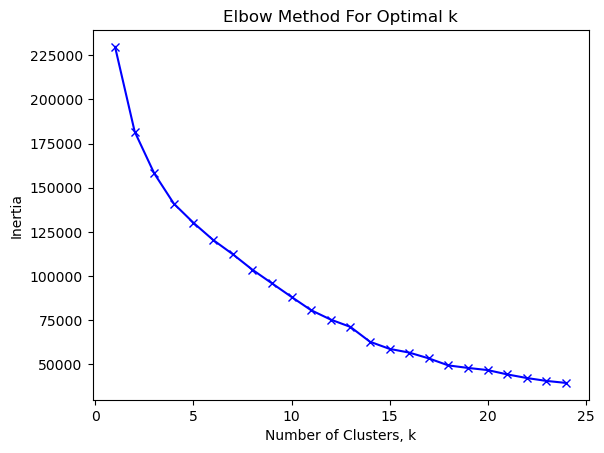

In [34]:
inertia = []
K_range = range(1, 25)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=73, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters, k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.savefig('../images/elbow_method_kmeans.png')
plt.show()

# Silhouette Score:

k=2, Silhouette Score=0.37207917753258185
k=3, Silhouette Score=0.21556881755568685
k=4, Silhouette Score=0.23464903174940946
k=5, Silhouette Score=0.25076259149856006
k=6, Silhouette Score=0.24949839855035377
k=7, Silhouette Score=0.23701661968449647
k=8, Silhouette Score=0.28165240540427505
k=9, Silhouette Score=0.2817627857266774
k=10, Silhouette Score=0.3124162225107529
k=11, Silhouette Score=0.3040366114945522
k=12, Silhouette Score=0.35059921643897296
k=13, Silhouette Score=0.3381157343902938
k=14, Silhouette Score=0.36186797012136396
k=15, Silhouette Score=0.3746746620159426
k=16, Silhouette Score=0.391342332881242
k=17, Silhouette Score=0.3896618069995332
k=18, Silhouette Score=0.4122888653936144
k=19, Silhouette Score=0.4168653983935883
k=20, Silhouette Score=0.4129507818846255
k=21, Silhouette Score=0.4257563957484461
k=22, Silhouette Score=0.4375629876270749
k=23, Silhouette Score=0.4542381133203927
k=24, Silhouette Score=0.40758885974370407


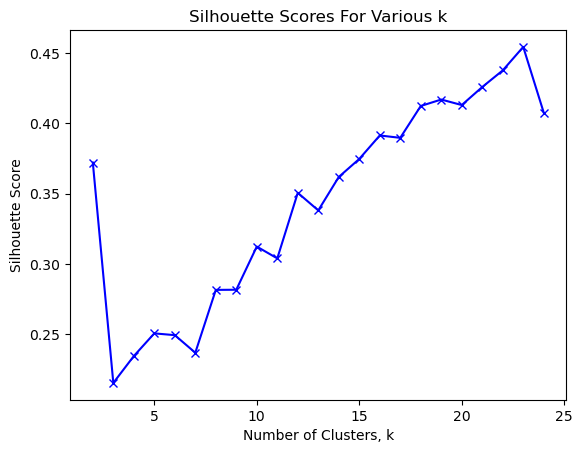

In [35]:
sil_scores = []
k_range = range(2, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=73, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    sil_scores.append(sil_score)
    print(f'k={k}, Silhouette Score={sil_score}')

plt.plot(k_range, sil_scores, 'bx-')
plt.xlabel('Number of Clusters, k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores For Various k')
plt.savefig('../images/silhouette_scores_kmeans.png')
plt.show()

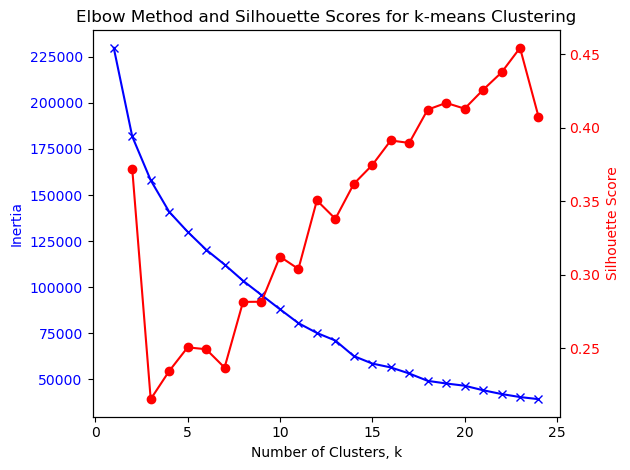

In [36]:
# Plotting both Elbow Method and Silhouette Scores together
fig, ax1 = plt.subplots()
ax1.plot(K_range, inertia, 'bx-', label='Inertia (Elbow Method)')
ax1.set_xlabel('Number of Clusters, k')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Elbow Method and Silhouette Scores for k-means Clustering')
fig.tight_layout()
plt.savefig('../images/elbow_silhouette_kmeans.png')
plt.show()

# Optimal k = 9

In [21]:
optimal_k = 8
model = KMeans(n_clusters=optimal_k, random_state=73, n_init=10)
X['cluster'] = model.fit_predict(X_scaled)

X.head(10)

,Assessment Time Epoch,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,cluster
0,1.146010e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
1,1.179878e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2,1.210810e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
3,1.241222e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
4,1.332893e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
5,1.386288e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
6,1.424995e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
7,1.508544e+09,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
8,1.146010e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,7
9,1.180051e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,7


In [22]:
# Using PCA for X_scaled array (26 features) to 2 components for visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
X_pca_df['cluster'] = X['cluster']
X_pca_df.head()

,PCA1,PCA2,cluster
0,-1.136810,-0.299088,1
1,-1.134587,-0.298858,1
2,-1.132557,-0.298647,1
3,-1.130560,-0.298440,1
4,-1.124544,-0.297816,1


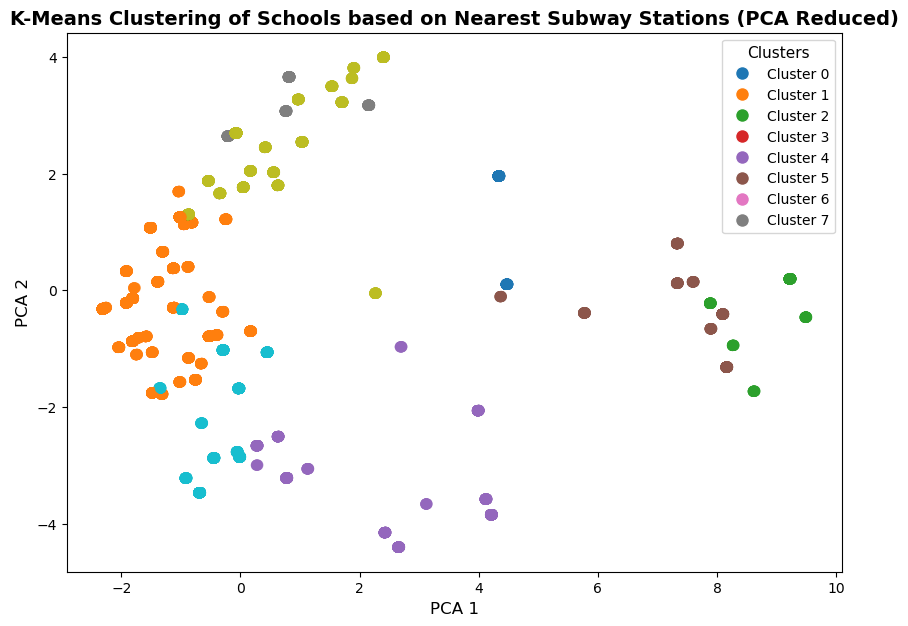

In [23]:
# Plotting X_pca_df

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_df['PCA1'], X_pca_df['PCA2'], c=X_pca_df['cluster'], cmap='tab10', alpha=0.7, s=50)
plt.xlabel('PCA 1', fontsize=12)
plt.ylabel('PCA 2', fontsize=12)
plt.title('K-Means Clustering of Schools based on Nearest Subway Stations (PCA Reduced)', fontsize=14, fontweight='bold')

# Add legend
unique_clusters = sorted(X_pca_df['cluster'].unique())
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab10(i/10), markersize=10, label=f'Cluster {cluster}') 
           for i, cluster in enumerate(unique_clusters)]
plt.legend(handles=handles, loc='best', fontsize=10, title='Clusters', title_fontsize=11)

plt.savefig('../images/kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# Re-joining school building numbers and QR scores

clustered_df = pd.merge(X[['cluster']], schools_w_mta, left_index=True, right_index=True, how='inner')
clustered_df.head()

,cluster,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,Assessment Time Epoch
0,1,K337,40.59928,-73.99644,30600,11214,2006-04-26,6,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.146010e+09
1,1,K337,40.59928,-73.99644,30600,11214,2007-05-23,1,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.179878e+09
2,1,K337,40.59928,-73.99644,30600,11214,2008-05-15,7,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.210810e+09
3,1,K337,40.59928,-73.99644,30600,11214,2009-05-02,7,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.241222e+09
4,1,K337,40.59928,-73.99644,30600,11214,2012-03-28,5,"[D, N]",0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1.332893e+09


In [25]:
# Separating out the schools by cluster for further analysis

clustered_schools = {}
for cluster_num in range(optimal_k):
    clustered_schools[cluster_num] = clustered_df[clustered_df['cluster'] == cluster_num]

clustered_schools[3]

,cluster,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,Assessment Time Epoch
2647,3,M459,40.76472,-73.96332,11800,10065,2006-04-05,6,"[Q, W, M, 4, F, E, N, R, 5, 6]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.144195e+09
2648,3,M459,40.76472,-73.96332,11800,10065,2007-05-24,1,"[Q, W, M, 4, F, E, N, R, 5, 6]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.179965e+09
2649,3,M459,40.76472,-73.96332,11800,10065,2008-05-23,6,"[Q, W, M, 4, F, E, N, R, 5, 6]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.211501e+09
2650,3,M459,40.76472,-73.96332,11800,10065,2012-05-09,6,"[Q, W, M, 4, F, E, N, R, 5, 6]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.336522e+09
2651,3,M459,40.76472,-73.96332,11800,10065,2015-04-03,0,"[Q, W, M, 4, F, E, N, R, 5, 6]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.428019e+09
2652,3,M459,40.76472,-73.96332,11800,10065,2019-11-23,0,"[Q, W, M, 4, F, E, N, R, 5, 6]",0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,1,1,0,1,0,1.574467e+09
2660,3,M294,40.71597,-73.98692,1800,10002,2006-04-07,7,"[Q, W, Z, M, F, J, B, N, L, D, R, 6]",0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,1,1,1,1,1,0,1,1,1.144368e+09
2661,3,M294,40.71597,-73.98692,1800,10002,2007-05-26,1,"[Q, W, Z, M, F, J, B, N, L, D, R, 6]",0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,1,1,1,1,1,0,1,1,1.180138e+09
2662,3,M294,40.71597,-73.98692,1800,10002,2008-03-07,7,"[Q, W, Z, M, F, J, B, N, L, D, R, 6]",0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,1,1,1,1,1,0,1,1,1.204848e+09
2663,3,M294,40.71597,-73.98692,1800,10002,2014-03-06,6,"[Q, W, Z, M, F, J, B, N, L, D, R, 6]",0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,1,1,1,1,1,0,1,1,1.394064e+09


In [26]:
# Showing summary statistics for each cluster
for cluster_num in range(optimal_k):
    print(f"Cluster {cluster_num} Subway Line Count:")
    print(f"Total Schools in Cluster: {len(clustered_schools[cluster_num])}")
    for line in subway_encoded_df.columns:
        line_count = clustered_schools[cluster_num][line].sum()
        print(f"  {line}: {line_count}")
    print("\n")

Cluster 0 Subway Line Count:
Total Schools in Cluster: 234
  1: 0
  2: 234
  3: 234
  4: 234
  5: 234
  6: 0
  7: 0
  A: 162
  B: 234
  C: 234
  D: 234
  E: 0
  F: 162
  FS: 0
  G: 234
  GS: 0
  J: 72
  L: 0
  M: 72
  N: 234
  Q: 234
  R: 234
  RS: 0
  W: 0
  Z: 72


Cluster 1 Subway Line Count:
Total Schools in Cluster: 4142
  1: 251
  2: 625
  3: 0
  4: 222
  5: 861
  6: 656
  7: 194
  A: 372
  B: 181
  C: 49
  D: 360
  E: 0
  F: 392
  FS: 0
  G: 191
  GS: 0
  J: 0
  L: 204
  M: 120
  N: 421
  Q: 336
  R: 256
  RS: 37
  W: 21
  Z: 0


Cluster 2 Subway Line Count:
Total Schools in Cluster: 162
  1: 162
  2: 150
  3: 150
  4: 150
  5: 150
  6: 162
  7: 162
  A: 131
  B: 162
  C: 131
  D: 162
  E: 131
  F: 162
  FS: 0
  G: 0
  GS: 162
  J: 0
  L: 63
  M: 162
  N: 162
  Q: 162
  R: 162
  RS: 0
  W: 162
  Z: 0


Cluster 3 Subway Line Count:
Total Schools in Cluster: 637
  1: 0
  2: 0
  3: 0
  4: 113
  5: 113
  6: 266
  7: 287
  A: 0
  B: 145
  C: 0
  D: 145
  E: 366
  F: 571
  FS: 0
  G: 

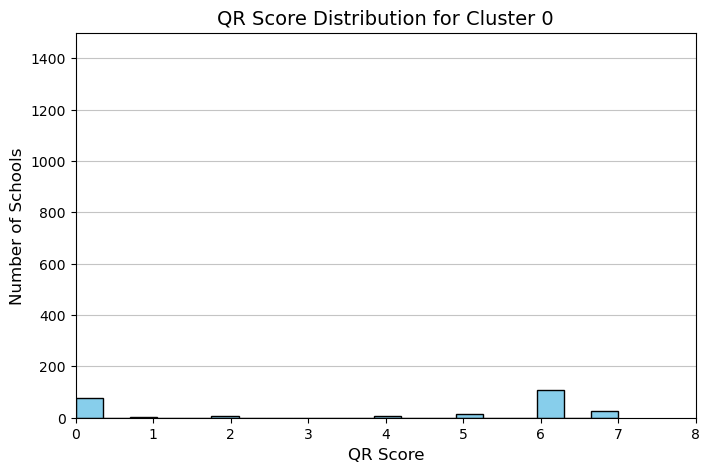

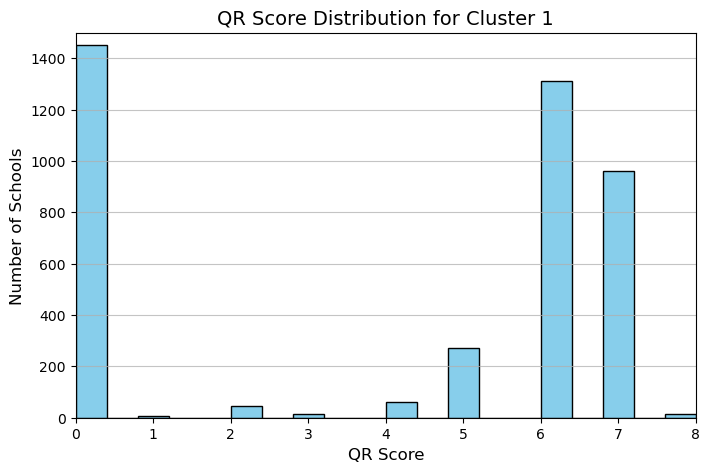

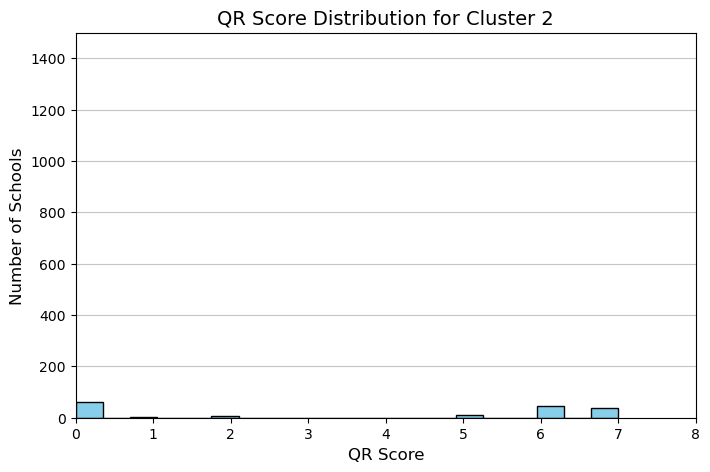

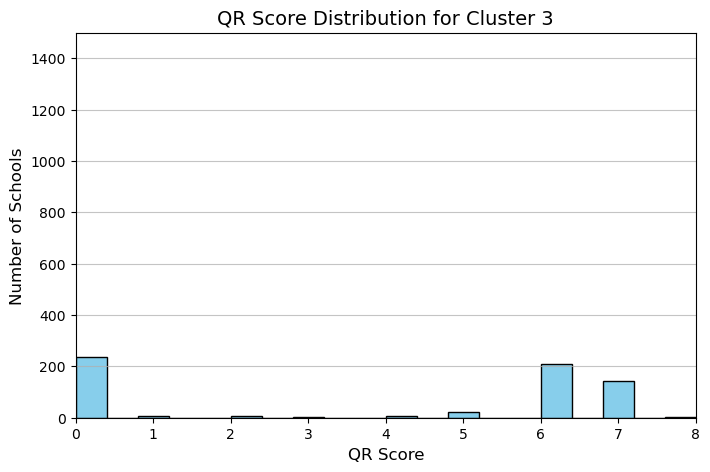

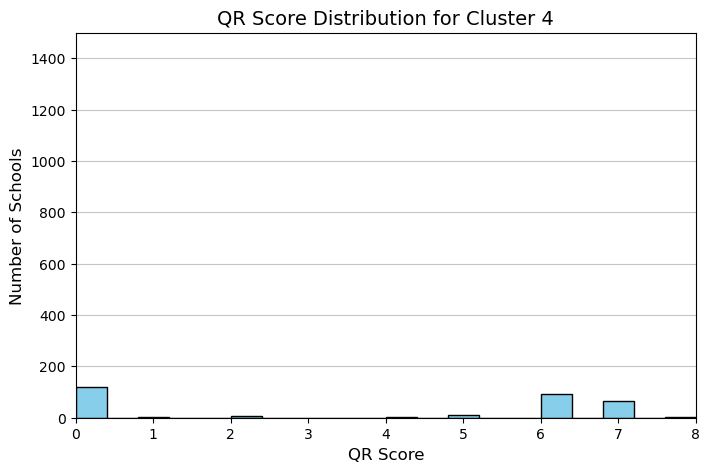

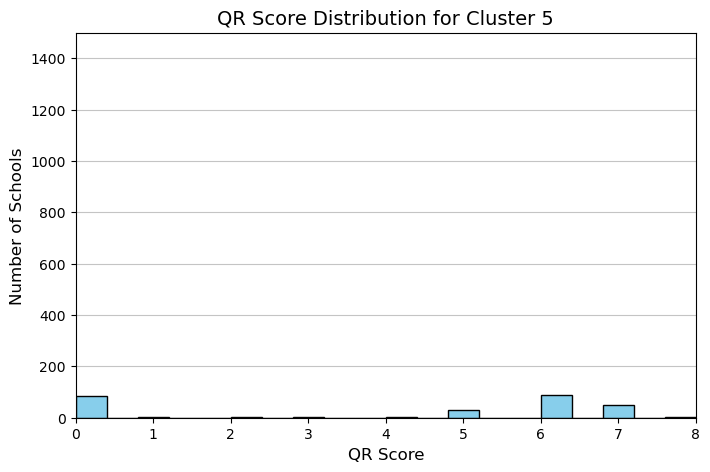

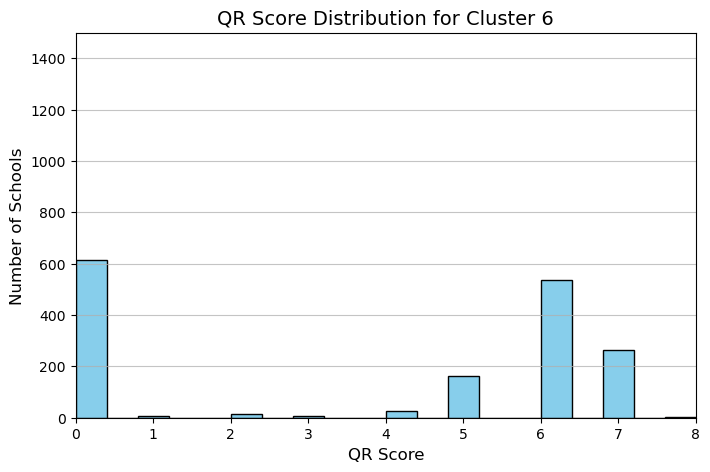

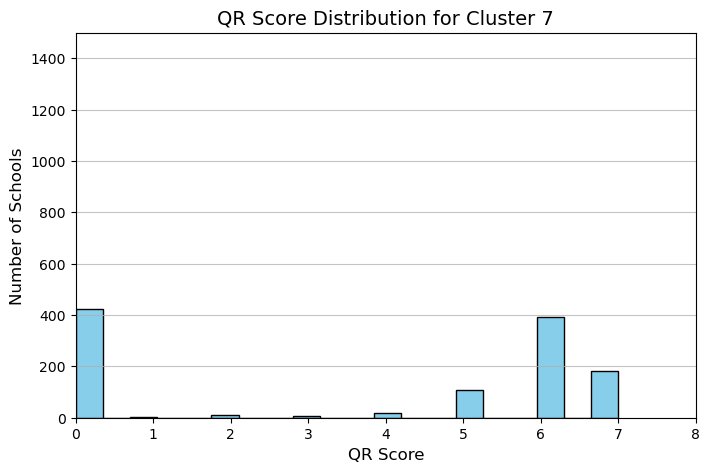

In [ ]:
# Plotting QR Score distributions for each cluster
for cluster_num in range(optimal_k):
    plt.figure(figsize=(8, 5))
    # keeping the scale consistent across graphs
    plt.xlim(0, 8)
    plt.ylim(0, 1500)
    plt.hist(clustered_schools[cluster_num]['QR Score'].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(f'QR Score Distribution for Cluster {cluster_num}', fontsize=14)
    plt.xlabel('QR Score', fontsize=12)
    plt.ylabel('Number of Schools', fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    #plt.savefig(f'../images/qr_score_distribution_cluster_{cluster_num}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Note:
- Cluster 1 is massive, containing nearly half the data

# Approach:
- Drop rows that have QR Scores = 0
- Drop rows that have no nearest subway stations (if this is indeed the case, double check first w samples)

In [ ]:
subway_df['mta_performance_data'].head()

0    [['2015-01-01', 76.2337806, 1], ['2015-02-01',...
1    [['2015-01-01', 47.2874494, 1], ['2015-02-01',...
2    [['2015-01-01', 68.6321563, 1], ['2015-02-01',...
3    [['2015-01-01', 48.4323757, 1], ['2015-02-01',...
4    [['2015-01-01', 49.3452473, 1], ['2015-02-01',...
Name: mta_performance_data, dtype: object

In [ ]:
# Showing rows by cluster:

clustered_schools[3].sample(10)

,cluster,School Building Number,Latitude,Longitude,Census Tract,Zip,Assessment Time,QR Score,Nearest_Subway_Stations,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,Assessment Time Epoch
5215,3,Q229,40.74483,-73.90516,51300,11377,2014-02-06,7,"[M, F, E, R, 7]",0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1.391645e+09
3893,3,M188,40.71597,-73.98692,2000,10002,2011-12-07,5,"[Q, W, Z, M, F, J, B, N, L, D, R, 6]",0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,1,1,1,1,1,0,1,1,1.323216e+09
6012,3,Q686,40.72315,-73.84373,64500,11375,2018-05-05,0,"[R, M, F, E]",0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1.525478e+09
3075,3,M142,40.71597,-73.98692,1402,10002,2007-01-18,6,"[Q, W, Z, M, F, J, B, N, L, D, R, 6]",0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,1,1,1,1,1,0,1,1,1.169078e+09
5956,3,Q296,40.73892,-73.87854,46300,11373,2016-03-05,0,"[M, F, E, R, 7]",0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1.457136e+09
2696,3,M696,40.71597,-73.98692,1002,10002,2008-05-10,6,"[Q, W, Z, M, F, J, B, N, L, D, R, 6]",0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,1,1,1,1,1,0,1,1,1.210378e+09
5443,3,Q445,40.76261,-73.91334,16300,11103,2008-04-02,6,"[R, M, W, N]",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,1,0,1.207094e+09
5639,3,Q126,40.76191,-73.93169,7700,11106,2014-12-13,0,"[W, M, F, E, N, R, 7]",0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,1,0,1,0,1,0,1.418429e+09
3998,3,M515,40.71597,-73.98692,3001,10002,2014-12-07,0,"[Q, W, Z, M, F, J, B, N, L, D, R, 6]",0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,1,1,1,1,1,0,1,1,1.417910e+09
3141,3,M158,40.77342,-73.95642,13200,10075,2012-01-11,7,"[Q, W, M, 4, N, R, 5, 6]",0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,1,0,1.326240e+09


In [ ]:
clustered_schools[3].describe()

,cluster,Latitude,Longitude,Assessment Time,QR Score,1,2,3,4,5,6,7,A,B,C,D,E,F,FS,G,GS,J,L,M,N,Q,R,RS,W,Z,Assessment Time Epoch
count,637.0,637.000000,637.000000,637,637.000000,637.0,637.0,637.0,637.000000,637.000000,637.000000,637.000000,637.0,637.000000,637.0,637.000000,637.000000,637.000000,637.0,637.000000,637.0,637.000000,637.000000,637.0,637.000000,637.000000,637.000000,637.0,637.000000,637.000000,6.370000e+02
mean,3.0,40.740080,-73.936100,2012-04-13 00:11:18.178963968,3.832025,0.0,0.0,0.0,0.177394,0.177394,0.417582,0.450549,0.0,0.227630,0.0,0.227630,0.574568,0.896389,0.0,0.150706,0.0,0.321821,0.321821,1.0,0.712716,0.417582,0.979592,0.0,0.712716,0.321821,1.334276e+09
min,3.0,40.715970,-73.986920,2006-04-05 00:00:00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.144195e+09
25%,3.0,40.723150,-73.978650,2008-03-26 00:00:00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,1.000000,0.0,0.000000,0.0,0.000000,0.000000,1.0,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,1.206490e+09
50%,3.0,40.744830,-73.939160,2012-01-11 00:00:00,6.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1.000000,1.000000,0.0,0.000000,0.0,0.000000,0.000000,1.0,1.000000,0.000000,1.000000,0.0,1.000000,0.000000,1.326240e+09
75%,3.0,40.751720,-73.905160,2015-05-13 00:00:00,6.000000,0.0,0.0,0.0,0.000000,0.000000,1.000000,1.000000,0.0,0.000000,0.0,0.000000,1.000000,1.000000,0.0,0.000000,0.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.431475e+09
max,3.0,40.773420,-73.843730,2020-03-12 00:00:00,8.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,0.0,1.000000,1.000000,1.000000,0.0,1.000000,0.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.583971e+09
std,0.0,0.018591,0.044461,NaN,3.095195,0.0,0.0,0.0,0.382302,0.382302,0.493548,0.497940,0.0,0.419632,0.0,0.419632,0.494797,0.304994,0.0,0.358044,0.0,0.467542,0.467542,0.0,0.452851,0.493548,0.141503,0.0,0.452851,0.467542,1.313953e+08
